In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import scipy
import numpy as np
import pandas as pd

from pathlib import Path
import soundfile as sf
from tqdm import tqdm
from sklearn.cluster import KMeans

In [2]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from cfg import get_config

In [3]:
def collect_channels(filepath, samplingrate, offset, duration_in_secs):
    channels = [[], [], [], [], [], [], [], []]

    with open(filepath, "rb") as rawFile:

        rawFile.seek(int(2*8*samplingrate*offset), 0)
        for i in range(samplingrate*duration_in_secs):
            for j in range(8):
                bytes = rawFile.read(2)
                sample_int = int.from_bytes(bytes = bytes, byteorder = "little", signed = True)
                sample_float = sample_int * (5 / 32768)

                channels[j].append(sample_float)

    return np.array(channels)

In [4]:
def plot_audio_seg_spec(audio_features, spec_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg+1e-6, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.colorbar()
    plt.show()

def plot_audio_seg_signal(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"Signal of {audio_features['plot_title']}", fontsize=24)
    plt.plot(audio_seg)
    plot_xtype = 'float'
    plt.xlim(0, duration*fs)
    plt.ylim(-5, 5)
    plt.grid(which='both')
    plt.xticks(ticks=np.linspace(0, audio_features['duration']*fs, 11), 
                labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Voltage (V)")
    plt.xlabel("Time (s)")
    plt.show()

def plot_audio_seg_fft(audio_features):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 18})
    plt.title(f"FFT of {audio_features['plot_title']}", fontsize=24)
    abs_sig = np.abs(scipy.fft.rfft(audio_seg, n=len(audio_seg)))
    abs_sig = abs_sig / len(abs_sig)
    plt.plot(20*np.log10(abs_sig/np.max(abs_sig)))
    plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, len(abs_sig), 11), 
                labels=np.round(np.linspace(0, (fs/2), 11, dtype=plot_xtype), 2)/1e3, rotation=30)
    plt.ylabel("Voltage (dB)")
    plt.xlabel("Frequency (kHz)")
    plt.grid(which='both')
    plt.show()
    
FREQ_COLORS = {'LF':'cyan',
               'HF':'orange'}

def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor=FREQ_COLORS[row['KMEANS_CLASSES']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace(start, start+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()

In [5]:
fs = 250000
file_dir = Path('/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array')
filepath = file_dir / 'hour_0.raw'

In [6]:
cfg = get_config()
cfg['tmp_dir'] = Path('../output/tmp')
cfg['run_model'] = True
cfg['should_csv'] = True
cfg['save'] = True

In [7]:
LABEL_FOR_GROUPS = {
                    0: 'LF', 
                    1: 'HF'
                    }

def get_snr_from_band_limited_signal(snr_call_signal, snr_noise_signal): 

    signal_power_rms = np.sqrt(np.square(snr_call_signal).mean())
    noise_power_rms = np.sqrt(np.square(snr_noise_signal).mean())
    snr = abs(20 * np.log10(signal_power_rms / noise_power_rms))

    return snr

def bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    high_cutoff =  (high_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, [low_cutoff, high_cutoff], btype='band', analog=False)
    band_limited_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return band_limited_audio_seg

def highpass_audio_signal(audio_seg, fs, low_freq_cutoff):
    nyq = fs // 2
    low_cutoff = (low_freq_cutoff) / nyq
    b, a = scipy.signal.butter(4, low_cutoff, btype='high', analog=False)
    high_passed_audio_seg = scipy.signal.filtfilt(b, a, audio_seg)

    return high_passed_audio_seg

def compute_welch_psd_of_call(call, fs, audio_info):
    freqs, welch = scipy.signal.welch(call, fs=fs, detrend=False, scaling='spectrum')
    cropped_welch = welch[(freqs<=audio_info['max_freq_visible'])]
    audio_spectrum_mag = np.abs(cropped_welch)
    audio_spectrum_db =  10*np.log10(audio_spectrum_mag)
    normalized_audio_spectrum_db = audio_spectrum_db - audio_spectrum_db.max()

    thresh = -100
    peak_db = np.zeros(len(normalized_audio_spectrum_db))+thresh
    peak_db[normalized_audio_spectrum_db>=thresh] = normalized_audio_spectrum_db[normalized_audio_spectrum_db>=thresh]

    original_freq_vector = np.arange(0, len(peak_db), 1).astype('int')
    common_freq_vector = np.linspace(0, len(peak_db)-1, audio_info['num_points']).astype('int')
    interp_kind = 'linear'
    interpolated_points_from_welch = scipy.interpolate.interp1d(original_freq_vector, peak_db, kind=interp_kind)(common_freq_vector)

    return interpolated_points_from_welch

def gather_features_of_interest(dets, kmean_welch, audio_file):
    fs = audio_file.samplerate
    features_of_interest = dict()
    features_of_interest['call_signals'] = []
    features_of_interest['welch_signals'] = []
    features_of_interest['snrs'] = []
    features_of_interest['peak_freqs'] = []
    features_of_interest['classes'] = []
    nyquist = fs//2
    for index, row in dets.iterrows():
        audio_seg, length_of_section = batdetect2_pipeline.get_section_of_call_in_file(row, audio_file)
        
        freq_pad = 2000
        low_freq_cutoff = row['low_freq']-freq_pad
        high_freq_cutoff = min(nyquist-1, row['high_freq']+freq_pad)
        band_limited_audio_seg = bandpass_audio_signal(audio_seg, fs, low_freq_cutoff, high_freq_cutoff)

        signal = band_limited_audio_seg.copy()
        signal[:int(fs*(length_of_section))] = 0
        noise = band_limited_audio_seg - signal
        snr_call_signal = signal[-int(fs*length_of_section):]
        snr_noise_signal = noise[:int(fs*length_of_section)]
        features_of_interest['call_signals'].append(snr_call_signal)

        high_passed_audio_seg = highpass_audio_signal(audio_seg, fs, 15000)
        snr_mod_signal = audio_seg.copy()
        snr_mod_signal[:int(fs*(length_of_section))] = 0
        snr_mod_noise = audio_seg - snr_mod_signal
        snr_mod_call_signal = snr_mod_signal[-int(fs*length_of_section):]
        snr_mod_noise_signal = snr_mod_noise[:int(fs*length_of_section)]
        snr = batdetect2_pipeline.get_snr_from_band_limited_signal(snr_mod_call_signal, snr_mod_noise_signal)
        features_of_interest['snrs'].append(snr)

        welch_info = dict()
        welch_info['num_points'] = 100
        max_visible_frequency = 96000
        welch_info['max_freq_visible'] = max_visible_frequency
        welch_signal = compute_welch_psd_of_call(snr_call_signal, fs, welch_info)
        features_of_interest['welch_signals'].append(welch_signal)

        peaks = np.where(welch_signal==max(welch_signal))[0][0]
        features_of_interest['peak_freqs'].append((max_visible_frequency/len(welch_signal))*peaks)
        
        welch_signal = (welch_signal).reshape(1, len(welch_signal))
        features_of_interest['classes'].append(kmean_welch.predict(welch_signal)[0])

    features_of_interest['call_signals'] = np.array(features_of_interest['call_signals'], dtype='object')

    return features_of_interest

def open_and_get_call_info(audio_file, dets):
    welch_key = 'all_locations'
    output_dir = Path(f'/Users/adityakrishna/duty-cycle-investigation/data/generated_welch/{welch_key}')
    output_file_type = 'top1_inbouts_welch_signals'
    welch_data = pd.read_csv(output_dir / f'2022_{welch_key}_{output_file_type}.csv', index_col=0, low_memory=False)
    k = 2
    kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=1).fit(welch_data.values)

    features_of_interest = gather_features_of_interest(dets, kmean_welch, audio_file)

    dets.reset_index(drop=True, inplace=True)

    dets['sampling_rate'] = len(dets) * [audio_file.samplerate]
    dets.insert(0, 'SNR', features_of_interest['snrs'])
    dets.insert(0, 'peak_frequency', features_of_interest['peak_freqs'])
    dets.insert(0, 'KMEANS_CLASSES', pd.Series(features_of_interest['classes']).map(LABEL_FOR_GROUPS))

    return features_of_interest['call_signals'], dets

def classify_calls_from_file(bd2_predictions, data_params):
    file_path = Path(data_params['audio_file'])
    audio_file = sf.SoundFile(file_path)
    call_signals, dets = open_and_get_call_info(audio_file, bd2_predictions.copy())
    return dets

def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_preds_classed = classify_calls_from_file(bd_annotations_df, cur_seg['audio_seg'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_preds_classed,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])

    median_peak_HF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='HF']['peak_frequency'].median()
    median_peak_LF_freq = bd_dets[bd_dets['KMEANS_CLASSES']=='LF']['peak_frequency'].median()
    print(f'Median LF frequency in File: {median_peak_LF_freq}')
    print(f'Median HF frequency in File: {median_peak_HF_freq}')
    lf_inds = (bd_dets['peak_frequency']<median_peak_LF_freq+7000)&(bd_dets['peak_frequency']>median_peak_LF_freq-7000)
    hf_inds = (bd_dets['peak_frequency']>median_peak_HF_freq-7000)

    lf_dets = bd_dets[lf_inds&(bd_dets['KMEANS_CLASSES']=='LF')]
    hf_dets = bd_dets[hf_inds&(bd_dets['KMEANS_CLASSES']=='HF')]

    all_dets = pd.concat([hf_dets, lf_dets]).sort_index()
    return all_dets

In [8]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)


    if (cfg['run_model']):
        cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
        filepath = (cfg['output_dir'] / f'{cfg["csv_filename"]}.csv')
        if not(filepath.is_file()):
            print(f'Generating detections from {file}')
            segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
            file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
            bd_preds = run_models(file_path_mappings)
            if cfg['save']:
                batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
            batdetect2_pipeline.delete_segments(segmented_file_paths)
        else:
            bd_preds = pd.read_csv(filepath)

    return bd_preds

In [9]:
all_dets = pd.DataFrame()

In [10]:
for offset in np.arange(0, 3600, 120):
    duration_in_secs = 120
    print(f'Examining {int(offset)} to {int(offset+duration_in_secs)}s')
    write_dir = Path(f'/Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/{filepath.stem}_{int(offset)}to{int(offset+duration_in_secs)}')
    if not (len(list((write_dir).glob('*.WAV')))==8):
        write_dir.mkdir(parents=True, exist_ok=True)
        print(f'Extracting data from {filepath.stem} and saving to {write_dir}')
        channels = collect_channels(filepath, fs, offset, duration_in_secs)

    for selected_channel in np.arange(0, 8, 1).astype(int):
        write_file = write_dir / f'{filepath.stem}_channel{selected_channel}_{int(offset)}to{int(offset+duration_in_secs)}.WAV'
        if not(write_file.exists()):
            print(f'Writing to {write_file}')
            audio_seg = channels[selected_channel]
            print(f'Data extracted from channel {selected_channel} (2mins)')

            sf.write(write_file, audio_seg, int(fs), subtype='FLOAT')
            print(f'Data written to {write_file}')

        recorded_audio = sf.SoundFile(write_file)
        audio_seg = recorded_audio.read(int(fs*duration_in_secs))

        fft_sig = scipy.fft.rfft(audio_seg, n=len(audio_seg))
        abs_sig = np.abs(fft_sig / len(fft_sig))
        dB_sig = 20*np.log10(abs_sig/np.max(abs_sig))
        relevantband = dB_sig[120*40000:120*80000]

        if np.sum(relevantband>-25) > 0:
            cfg['output_dir'] = write_dir
            cfg['input_audio'] = Path(write_file)
            dets = run_pipeline_on_file(write_file, cfg)
            if len(dets)>0:
                print(f'Plotting data from {write_file}')
                vmax = -20
                vmin = -80

                audio_features = dict()
                audio_features['figsize'] = (15, 5)
                audio_features['file_path'] = write_file
                audio_features['audio_seg'] = audio_seg
                audio_features['sample_rate'] = fs
                audio_features['start'] = offset
                audio_features['duration'] = duration_in_secs

                spec_features = dict()
                spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
                spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
                spec_features['vmin'] = vmin
                spec_features['vmax'] = vmax

                audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {selected_channel+1})"
                # plot_audio_seg_signal(audio_features)
                # plot_audio_seg_spec(audio_features, spec_features)
                plot_dets = dets.copy()
                plot_dets['start_time'] += offset
                plot_dets['end_time'] += offset
                all_dets = pd.concat([all_dets, plot_dets])
                # plot_colored_dets_over_audio(audio_features, spec_features, plot_dets)
                # plot_audio_seg_fft(audio_features)

Examining 0 to 120s
Examining 120 to 240s
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_120to240/hour_0_channel3_120to240.WAV
Examining 240 to 360s
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel0_240to360.WAV
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel2_240to360.WAV
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel3_240to360.WAV
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel4_240to360.WAV
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channel5_240to360.WAV
Plotting data from /Volumes/Elements/UBNA_array_tests/mic_array_test_20241010/inUBNA/array/hour_0_240to360/hour_0_channe

Text(0.5, 0, 'SNR')

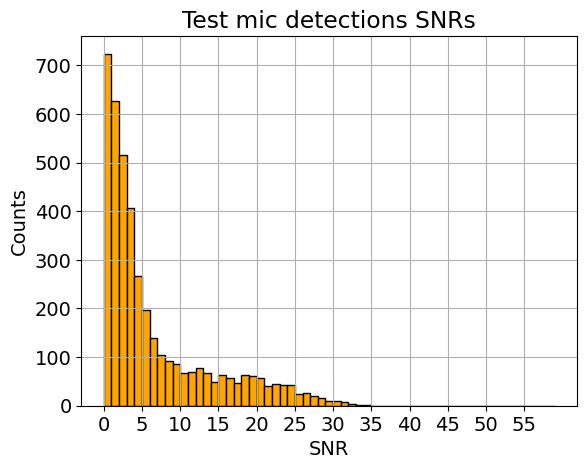

In [12]:
plt.rcParams.update({'font.size':14})
(all_dets['SNR'].sort_values()).hist(bins=np.arange(0, 60, 1), facecolor='orange', edgecolor='k', density=False)
# plt.yscale('log')
plt.title('Test mic detections SNRs')
plt.xticks(np.arange(0, 60, 5))
plt.ylabel('Counts')
plt.xlabel('SNR')